In [1]:
import math
import time
import copy
import zipfile
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset , DataLoader

SEED=139
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device : ", device)

using device :  cuda


## Loading Jena Dataset

In [2]:
import urllib.request
DATA_DIR = "jena_climate_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv.zip")
csv_path = os.path.join(DATA_DIR, "jena_climate_2009_2016.csv")

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"

if not os.path.exists(csv_path):
    if not os.path.exists(zip_path):
        print("Downloading Jena Climate dataset...")
        urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    print("Done.")
else:
    print("Dataset already present at", csv_path)

df_raw = pd.read_csv(csv_path)
print(df_raw.shape)
df_raw.head()

Dataset already present at jena_climate_data\jena_climate_2009_2016.csv
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## Downsampling

In [3]:
df = df_raw.copy()

df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time")

n_rows = len(df)
n_complete_hours = n_rows // 6
df_trimmed = df.iloc[:n_complete_hours*6]

group_id = np.arange(len(df_trimmed)) // 6
df_hourly = df_trimmed.groupby(group_id).mean() #taking average of 6 different columns of only

hourly_index = df_trimmed.index[::6][:len(df_hourly)]
df_hourly.index = hourly_index
df.index.name = "Date Time" 
df_hourly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.523333,-8.261667,265.161667,-9.063333,93.883333,3.271667,3.071667,0.200000,1.918333,3.081667,1308.973333,0.468333,0.940000,177.500000
2009-01-01 01:10:00,996.545000,-8.203333,265.221667,-9.026667,93.733333,3.288333,3.081667,0.205000,1.926667,3.093333,1308.713333,0.323333,0.711667,172.016667
2009-01-01 02:10:00,996.781667,-8.751667,264.653333,-9.591667,93.583333,3.146667,2.945000,0.200000,1.840000,2.955000,1311.805000,0.236667,0.606667,192.966667
2009-01-01 03:10:00,997.011667,-8.936667,264.450000,-9.846667,93.050000,3.101667,2.885000,0.215000,1.803333,2.891667,1313.051667,0.163333,0.565000,169.216667
2009-01-01 04:10:00,997.236667,-9.445000,263.923333,-10.450000,92.316667,2.980000,2.751667,0.231667,1.718333,2.756667,1315.951667,0.340000,0.753333,136.260000


## Split and Normalization

In [4]:
TargetCol = "T (degC)"
feature_cols = list(df_hourly.columns)
target_idx = feature_cols.index(TargetCol)

data = df_hourly[feature_cols].values.astype(np.float32)
n_total = len(data)

n_train = int(0.7*n_total)

train_data = data[:n_train]
test_data = data[n_train:]

mean = train_data.mean(axis=0, keepdims=True)
std = train_data.std(axis=0, keepdims=True) + 1e-8

train_norm = (train_data-mean)/std
test_norm = (test_data-mean)/std

target_mean = float(mean[0, target_idx])
target_std = float(std[0, target_idx])

In [5]:
INPUT_HOURS = 720
PRED_HOURS = 24

def make_windows(arr, input_len=INPUT_HOURS, pred_len=PRED_HOURS, target_idx=target_idx, stride=1):
    X,Y = [], []
    n = len(arr)
    last_start = n - input_len - pred_len
    for start in range(0, last_start+1, stride):
        x = arr[start:start+input_len]
        y = arr[start + input_len : start + input_len + pred_len, target_idx]
        X.append(x)
        Y.append(y)
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

# strides avoid overlapping and reduces the comustation cost
TRAIN_STRIDE = 6
EVAL_STRIDE = 24

X_train, y_train = make_windows(train_norm, stride=TRAIN_STRIDE)
X_test, y_test = make_windows(test_norm, stride=EVAL_STRIDE)

In [6]:
print("Train windows:", X_train.shape, y_train.shape)
print("Test windows: ", X_test.shape, y_test.shape)

Train windows: (8054, 720, 14) (8054, 24)
Test windows:  (846, 720, 14) (846, 24)


In [7]:
class WeatherWindowDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 64

train_ds = WeatherWindowDataset(X_train, y_train)
test_ds = WeatherWindowDataset(X_test, y_test)

train_loader = DataLoader(train_ds ,batch_size=BATCH_SIZE, shuffle = True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

n_features = X_train.shape[-1]

In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2,dtype=torch.float32) * (-math.log(10000.0)/d_model))

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:, 1::2]  = torch.cos(position*div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self,x):
        seq_len = x.size(1)
        x = x + self.pe[:,:seq_len,:]
        return x

In [9]:
class TimeSeriesTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=3,dim_feedforward=256, dropout=0.1, pred_len=PRED_HOURS, max_len=INPUT_HOURS+10):
        super().__init__()
        
        self.d_model = d_model
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len) #initialized Positional encoding

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="relu",
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        self.dropout = nn.Dropout(dropout)

        self.head = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, pred_len)
        )

    def forward(self, x):
        x = self.input_proj(x) * math.sqrt(self.d_model) # scaling embeddings
        x = self.pos_encoder(x)
        x = self.dropout(x)

        enc_out = self.encoder(x)

        last_hidden = enc_out[:, -1, :]
        out = self.head(last_hidden)
        return out

## Optimizer, Loss and Hyperparameters

In [10]:
D_MODEL = 64
NHEAD = 8
NUM_LAYERS = 3
DIM_FEEDFORWARD = 256
DROPOUT = 0.1
LR = 1e-4
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 15
GRAD_CLIP = 1.0

model = TimeSeriesTransformer(
    n_features=n_features,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    pred_len=PRED_HOURS,
    max_len=INPUT_HOURS + 10,
).to(device)

criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss()
criterion_huber = nn.HuberLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

## Training and Evaluation Loops

In [11]:
def run_epochs(model, loader, criterion_mse, criterion_mae, criterion_huber, target_mean, target_std, optimizer=None, grad_clip=None):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_mse = 0.0
    total_mae = 0.0
    total_huber = 0.0
    n_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            preds = model(X_batch)

            preds_actual = preds * target_std + target_mean
            y_actual = y_batch * target_std + target_mean

            mse_loss = criterion_mse(preds_actual, y_actual)
            mae_loss = criterion_mae(preds_actual, y_actual)
            huber_loss = criterion_huber(preds_actual, y_actual)

            if is_train:
                huber_loss.backward()
                if grad_clip is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                optimizer.step()
            
            batchSize = X_batch.size(0)
            total_mse += mse_loss.item()*batchSize
            total_mae += mae_loss.item()*batchSize
            total_huber += huber_loss.item()*batchSize
            n_samples += batchSize

    return total_mse/n_samples, total_mae/n_samples, total_huber/n_samples

## Training Loop

In [12]:
train_mse_losses, train_mae_losses, train_huber_losses = [], [], []
test_mse_losses, test_mae_losses, test_huber_losses = [], [], []
best_test_loss = float("inf")
best_state_dict = None

start_time = time.time()

for epoch in range(1,NUM_EPOCHS+1):
    epoch_start = time.time()

    train_mse, train_mae, train_huber = run_epochs(model, train_loader, criterion_mse, criterion_mae, criterion_huber, target_mean, target_std, optimizer, grad_clip=GRAD_CLIP)
    test_mse, test_mae, test_huber = run_epochs(model, test_loader, criterion_mse, criterion_mae, criterion_huber, target_mean, target_std, optimizer=None)
    scheduler.step(test_huber)

    train_mse_losses.append(train_mse)
    train_mae_losses.append(train_mae)
    train_huber_losses.append(train_huber)
    test_mse_losses.append(test_mse)
    test_mae_losses.append(test_mae)
    test_huber_losses.append(test_huber)

    if test_huber < best_test_loss:
        best_test_loss = test_huber
        best_state_dict = copy.deepcopy(model.state_dict())

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train MSE: {train_mse:.4f} MAE: {train_mae:.4f} Huber: {train_huber:.4f} | "
          f"test MSE: {test_mse:.4f} MAE: {test_mae:.4f} Huber: {test_huber:.4f} | "
          f"lr: {current_lr:.2e} | {epoch_time:.1f}s")

total_time = time.time() - start_time
print(f"\nTraining complete in {total_time/60:.1f} min. Best test Huber: {best_test_loss:.4f}")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

Epoch 01/15 | train MSE: 35.7201 MAE: 4.5434 Huber: 4.0696 | test MSE: 17.5375 MAE: 3.0665 Huber: 2.6068 | lr: 1.00e-04 | 43.4s
Epoch 02/15 | train MSE: 16.5339 MAE: 3.1328 Huber: 2.6691 | test MSE: 14.5744 MAE: 2.7915 Huber: 2.3351 | lr: 1.00e-04 | 43.2s
Epoch 03/15 | train MSE: 14.7240 MAE: 2.9590 Huber: 2.4976 | test MSE: 13.7391 MAE: 2.7054 Huber: 2.2513 | lr: 1.00e-04 | 43.3s
Epoch 04/15 | train MSE: 14.0798 MAE: 2.8888 Huber: 2.4288 | test MSE: 13.0968 MAE: 2.5930 Huber: 2.1436 | lr: 1.00e-04 | 43.4s
Epoch 05/15 | train MSE: 13.5422 MAE: 2.8369 Huber: 2.3776 | test MSE: 12.0645 MAE: 2.4988 Huber: 2.0511 | lr: 1.00e-04 | 43.5s
Epoch 06/15 | train MSE: 13.2705 MAE: 2.8058 Huber: 2.3470 | test MSE: 12.9948 MAE: 2.5809 Huber: 2.1304 | lr: 1.00e-04 | 43.5s
Epoch 07/15 | train MSE: 13.0890 MAE: 2.7862 Huber: 2.3277 | test MSE: 12.8036 MAE: 2.5874 Huber: 2.1359 | lr: 1.00e-04 | 43.7s
Epoch 08/15 | train MSE: 12.8840 MAE: 2.7670 Huber: 2.3089 | test MSE: 12.2647 MAE: 2.5065 Huber: 2.0575

## Loss Curves

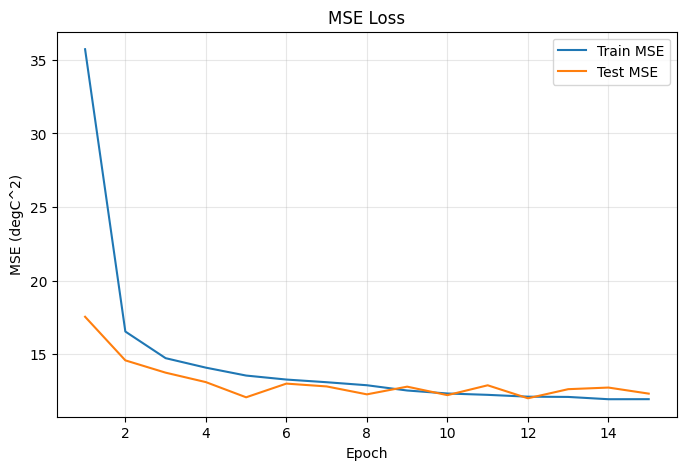

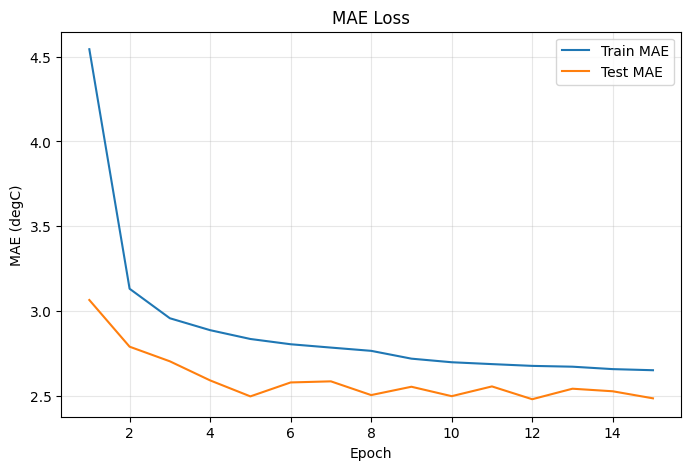

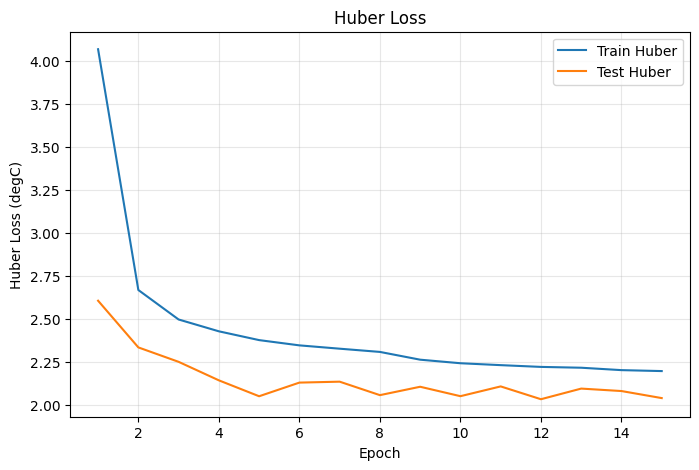

In [13]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_mse_losses)+1), train_mse_losses, label="Train MSE")
plt.plot(range(1, len(test_mse_losses)+1), test_mse_losses, label="Test MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE (degC^2)")
plt.title("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_mae_losses)+1), train_mae_losses, label="Train MAE")
plt.plot(range(1, len(test_mae_losses)+1), test_mae_losses, label="Test MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (degC)")
plt.title("MAE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_huber_losses)+1), train_huber_losses, label="Train Huber")
plt.plot(range(1, len(test_huber_losses)+1), test_huber_losses, label="Test Huber")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss (degC)")
plt.title("Huber Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

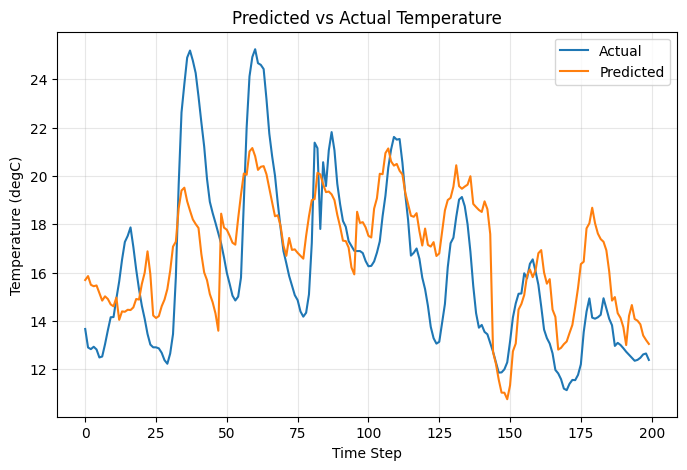

In [14]:
model.eval()
with torch.no_grad():
    X_sample = torch.from_numpy(X_test).to(device)
    y_sample = torch.from_numpy(y_test).to(device)
    preds_sample = model(X_sample)

preds_np = (preds_sample.cpu().numpy() * target_std + target_mean).flatten()
actual_np = (y_sample.cpu().numpy() * target_std + target_mean).flatten()

plt.figure(figsize=(8,5))
plt.plot(actual_np[:200], label="Actual")
plt.plot(preds_np[:200], label="Predicted")
plt.xlabel("Time Step")
plt.ylabel("Temperature (degC)")
plt.title("Predicted vs Actual Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.show()